In [1]:
import re
with open("the-verdict.txt", "r", encoding="utf-8") as f:

    raw_text = f.read()


print("Total number of character:", len(raw_text))

print(raw_text[:99])


Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [19]:
import importlib

import tiktoken


print("tiktoken version:", importlib.metadata.version("tiktoken"))


tiktoken version: 0.12.0


In [20]:
tokenizer = tiktoken.get_encoding("gpt2")


In [22]:
import tiktoken



encodings = {

    "gpt2": tiktoken.get_encoding("gpt2"),

    "gpt3": tiktoken.get_encoding("p50k_base"),

    "gpt4": tiktoken.get_encoding("cl100k_base")

}



vocab_sizes = {model: encoding.n_vocab for model, encoding in encodings.items()}



for model, size in vocab_sizes.items():

    print(f"The vocabulary size for {model.upper()} is: {size}")


The vocabulary size for GPT2 is: 50257
The vocabulary size for GPT3 is: 50281
The vocabulary size for GPT4 is: 100277


In [23]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:

    raw_text = f.read()


enc_text = tokenizer.encode(raw_text)

print(len(enc_text))


5145


In [24]:
enc_sample = enc_text[50:]


In [25]:
context_size = 4





x = enc_sample[:context_size]

y = enc_sample[1:context_size+1]


print(f"x: {x}")

print(f"y:      {y}")


x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [26]:
for i in range(1, context_size+1):

    context = enc_sample[:i]

    desired = enc_sample[i]


    print(context, "---->", desired)


[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [27]:
for i in range(1, context_size+1):

    context = enc_sample[:i]

    desired = enc_sample[i]


    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))


 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


In [28]:
from torch.utils.data import Dataset, DataLoader



class GPTDatasetV1(Dataset):

    def __init__(self, txt, tokenizer, max_length, stride):

        self.input_ids = []

        self.target_ids = []



        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})



        for i in range(0, len(token_ids) - max_length, stride):

            input_chunk = token_ids[i:i + max_length]

            target_chunk = token_ids[i + 1: i + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk))

            self.target_ids.append(torch.tensor(target_chunk))


    def __len__(self):

        return len(self.input_ids)


    def __getitem__(self, idx):

        return self.input_ids[idx], self.target_ids[idx]


In [29]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,

                         stride=128, shuffle=True, drop_last=True,

                         num_workers=0):



    tokenizer = tiktoken.get_encoding("gpt2")



    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)



    dataloader = DataLoader(

        dataset,

        batch_size=batch_size,

        shuffle=shuffle,

        drop_last=drop_last,

        num_workers=num_workers

    )


    return dataloader


In [30]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:

    raw_text = f.read()


In [31]:
import torch

print("PyTorch version:", torch.__version__)

dataloader = create_dataloader_v1(

    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False

)


data_iter = iter(dataloader)

first_batch = next(data_iter)

print(first_batch)


PyTorch version: 2.9.0+cu128
[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [32]:
second_batch = next(data_iter)

print(second_batch)


[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


In [33]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)


data_iter = iter(dataloader)

inputs, targets = next(data_iter)

print("Inputs:\n", inputs)

print("\nTargets:\n", targets)


Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


In [34]:
input_ids = torch.tensor([2, 3, 5, 1])


In [35]:
vocab_size = 6

output_dim = 3


torch.manual_seed(123)

embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [36]:
print(embedding_layer.weight)


Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [37]:
print(embedding_layer(torch.tensor([3])))


tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [38]:
print(embedding_layer(input_ids))


tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [39]:
vocab_size = 50257

output_dim = 256


token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [41]:
max_length = 4

dataloader = create_dataloader_v1(

    raw_text, batch_size=8, max_length=max_length,

    stride=max_length, shuffle=False

)

data_iter = iter(dataloader)

inputs, targets = next(data_iter)


In [42]:
print("Token IDs:\n", inputs)

print("\nInputs shape:\n", inputs.shape)


Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [43]:
token_embeddings = token_embedding_layer(inputs)

print(token_embeddings.shape)


torch.Size([8, 4, 256])


In [44]:
context_length = max_length

pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)


In [45]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))

print(pos_embeddings.shape)


torch.Size([4, 256])


In [46]:
input_embeddings = token_embeddings + pos_embeddings

print(input_embeddings.shape)


torch.Size([8, 4, 256])


In [47]:
import torch


inputs = torch.tensor(

  [[0.43, 0.15, 0.89],

   [0.55, 0.87, 0.66],

   [0.57, 0.85, 0.64],

   [0.22, 0.58, 0.33],

   [0.77, 0.25, 0.10],

   [0.05, 0.80, 0.55]]

)


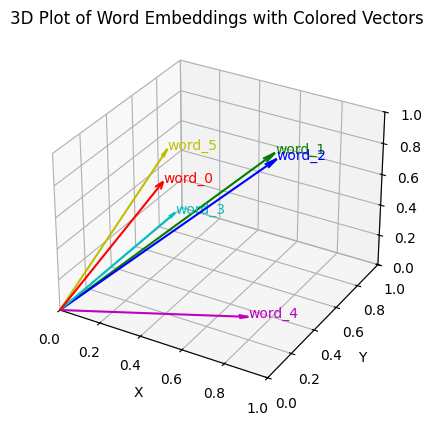

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()
words = ['word_0', 'word_1', 'word_2', 'word_3', 'word_4', 'word_5'] # Placeholder words

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):

    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

In [50]:
query = inputs[1]


attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):

    attn_scores_2[i] = torch.dot(x_i, query)


print(attn_scores_2)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [51]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()


print("Attention weights:", attn_weights_2_tmp)

print("Sum:", attn_weights_2_tmp.sum())


Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In [52]:
def softmax_naive(x):

    return torch.exp(x) / torch.exp(x).sum(dim=0)


attn_weights_2_naive = softmax_naive(attn_scores_2)


print("Attention weights:", attn_weights_2_naive)

print("Sum:", attn_weights_2_naive.sum())


Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [53]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights:", attn_weights_2)

print("Sum:", attn_weights_2.sum())


Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [54]:
query = inputs[1]


context_vec_2 = torch.zeros(query.shape)

for i,x_i in enumerate(inputs):

    context_vec_2 += attn_weights_2[i]*x_i


print(context_vec_2)


tensor([0.4419, 0.6515, 0.5683])


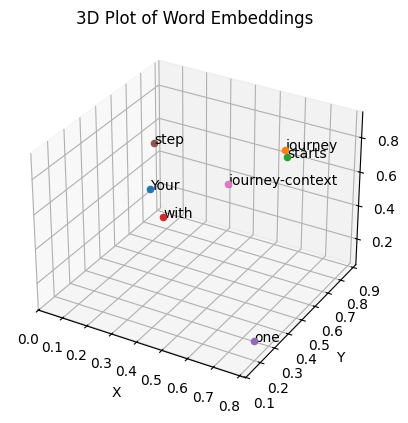

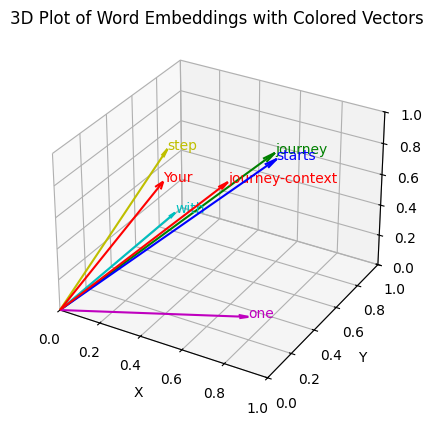

In [55]:
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D


inputs2 = torch.tensor(

  [[0.43, 0.15, 0.89],

   [0.55, 0.87, 0.66],

   [0.57, 0.85, 0.64],

   [0.22, 0.58, 0.33],

   [0.77, 0.25, 0.10],

   [0.05, 0.80, 0.55],

   [0.4419, 0.6515, 0.5683]]

)



words2 = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']



x_coords = inputs2[:, 0].numpy()

y_coords = inputs2[:, 1].numpy()

z_coords = inputs2[:, 2].numpy()



fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')



for x, y, z, word in zip(x_coords, y_coords, z_coords, words2):

    ax.scatter(x, y, z)

    ax.text(x, y, z, word, fontsize=10)



ax.set_xlabel('X')

ax.set_ylabel('Y')

ax.set_zlabel('Z')


plt.title('3D Plot of Word Embeddings')

plt.show()



fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')



colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']



for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words2, colors):


    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)

    ax.text(x, y, z, word, fontsize=10, color=color)



ax.set_xlabel('X')

ax.set_ylabel('Y')

ax.set_zlabel('Z')



ax.set_xlim([0, 1])

ax.set_ylim([0, 1])

ax.set_zlim([0, 1])


plt.title('3D Plot of Word Embeddings with Colored Vectors')

plt.show()


In [56]:
attn_scores = torch.empty(6, 6)


for i, x_i in enumerate(inputs):

    for j, x_j in enumerate(inputs):

        attn_scores[i, j] = torch.dot(x_i, x_j)


print(attn_scores)


tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [57]:
attn_scores = inputs @ inputs.T

print(attn_scores)


tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [58]:
attn_weights = torch.softmax(attn_scores, dim=-1)

print(attn_weights)


tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [59]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

print("Row 2 sum:", row_2_sum)

print("All row sums:", attn_weights.sum(dim=-1))


Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [60]:
all_context_vecs = attn_weights @ inputs

print(all_context_vecs)


tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [61]:
print("Previous 2nd context vector:", context_vec_2)


Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


In [62]:
import torch


inputs = torch.tensor(

  [[0.43, 0.15, 0.89],

   [0.55, 0.87, 0.66],

   [0.57, 0.85, 0.64],

   [0.22, 0.58, 0.33],

   [0.77, 0.25, 0.10],

   [0.05, 0.80, 0.55]]

)


In [63]:
x_2 = inputs[1]

d_in = inputs.shape[1]

d_out = 2


In [64]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)


In [65]:
print(W_query)


Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


In [67]:
print(W_value)


Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [68]:
query_2 = x_2 @ W_query

key_2 = x_2 @ W_key

value_2 = x_2 @ W_value

print(query_2)


tensor([0.4306, 1.4551])


In [69]:
keys = inputs @ W_key

values = inputs @ W_value

queries = inputs @ W_query

print("keys.shape:", keys.shape)


print("values.shape:", values.shape)


print("queries.shape:", queries.shape)


keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])
queries.shape: torch.Size([6, 2])


In [70]:
keys_2 = keys[1]

attn_score_22 = query_2.dot(keys_2)

print(attn_score_22)


tensor(1.8524)


In [71]:
attn_scores_2 = query_2 @ keys.T

print(attn_scores_2)


tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [72]:
attn_scores = queries @ keys.T

print(attn_scores)


tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


In [73]:
d_k = keys.shape[-1]

attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)

print(attn_weights_2)

print(d_k)


tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
2


In [74]:
import torch



tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])



softmax_result = torch.softmax(tensor, dim=-1)

print("Softmax without scaling:", softmax_result)



scaled_tensor = tensor * 8

softmax_scaled_result = torch.softmax(scaled_tensor, dim=-1)

print("Softmax after scaling (tensor * 8):", softmax_scaled_result)


Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling (tensor * 8): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


In [75]:
import numpy as np



def compute_variance(dim, num_trials=1000):

    dot_products = []

    scaled_dot_products = []



    for _ in range(num_trials):

        q = np.random.randn(dim)

        k = np.random.randn(dim)



        dot_product = np.dot(q, k)

        dot_products.append(dot_product)



        scaled_dot_product = dot_product / np.sqrt(dim)

        scaled_dot_products.append(scaled_dot_product)



    variance_before_scaling = np.var(dot_products)

    variance_after_scaling = np.var(scaled_dot_products)


    return variance_before_scaling, variance_after_scaling



variance_before_5, variance_after_5 = compute_variance(5)

print(f"Variance before scaling (dim=5): {variance_before_5}")

print(f"Variance after scaling (dim=5): {variance_after_5}")



variance_before_100, variance_after_100 = compute_variance(100)

print(f"Variance before scaling (dim=100): {variance_before_100}")

print(f"Variance after scaling (dim=100): {variance_after_100}")



Variance before scaling (dim=5): 4.953097943192443
Variance after scaling (dim=5): 0.9906195886384883
Variance before scaling (dim=100): 89.14419723694547
Variance after scaling (dim=100): 0.8914419723694548


In [76]:
context_vec_2 = attn_weights_2 @ values

print(context_vec_2)


tensor([0.3061, 0.8210])


In [77]:
import torch.nn as nn


class SelfAttention_v1(nn.Module):


    def __init__(self, d_in, d_out):

        super().__init__()

        self.W_query = nn.Parameter(torch.rand(d_in, d_out))

        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))

        self.W_value = nn.Parameter(torch.rand(d_in, d_out))


    def forward(self, x):

        keys = x @ self.W_key

        queries = x @ self.W_query

        values = x @ self.W_value


        attn_scores = queries @ keys.T

        attn_weights = torch.softmax(

            attn_scores / keys.shape[-1]**0.5, dim=-1

        )


        context_vec = attn_weights @ values

        return context_vec


In [78]:
torch.manual_seed(123)

sa_v1 = SelfAttention_v1(d_in, d_out)

print(sa_v1(inputs))


tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [79]:
class SelfAttention_v2(nn.Module):


    def __init__(self, d_in, d_out, qkv_bias=False):

        super().__init__()

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)


    def forward(self, x):

        keys = self.W_key(x)

        queries = self.W_query(x)

        values = self.W_value(x)


        attn_scores = queries @ keys.T

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)


        context_vec = attn_weights @ values

        return context_vec


In [80]:
torch.manual_seed(789)

sa_v2 = SelfAttention_v2(d_in, d_out)

print(sa_v2(inputs))


tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [81]:
inputs = torch.tensor(

  [[0.43, 0.15, 0.89],

   [0.55, 0.87, 0.66],

   [0.57, 0.85, 0.64],

   [0.22, 0.58, 0.33],

   [0.77, 0.25, 0.10],

   [0.05, 0.80, 0.55]]

)


In [82]:
queries = sa_v2.W_query(inputs)

keys = sa_v2.W_key(inputs)

attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)

print(attn_weights)


tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [83]:
torch.ones(context_length, context_length)


tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [84]:
context_length = attn_scores.shape[0]

mask_simple = torch.tril(torch.ones(context_length, context_length))

print(mask_simple)


tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [85]:
masked_simple = attn_weights*mask_simple

print(masked_simple)


tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [86]:
row_sums = masked_simple.sum(dim=1, keepdim=True)

masked_simple_norm = masked_simple / row_sums

print(masked_simple_norm)


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [87]:
print(attn_scores)


tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [88]:
torch.triu(torch.ones(context_length, context_length))


tensor([[1., 1., 1., 1., 1., 1.],
        [0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.]])

In [89]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)

print(mask)


tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


In [90]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)

masked = attn_scores.masked_fill(mask.bool(), -torch.inf)

print(masked)


tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [91]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)

print(attn_weights)


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [92]:
example = torch.ones(6, 6)

print(example)


tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])


In [93]:
torch.manual_seed(123)

dropout = torch.nn.Dropout(0.5)

example = torch.ones(6, 6)

print(dropout(example))


tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [94]:
torch.manual_seed(123)

print(dropout(attn_weights))


tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


In [95]:
inputs = torch.tensor(

  [[0.43, 0.15, 0.89],

   [0.55, 0.87, 0.66],

   [0.57, 0.85, 0.64],

   [0.22, 0.58, 0.33],

   [0.77, 0.25, 0.10],

   [0.05, 0.80, 0.55]]

)

batch = torch.stack((inputs, inputs), dim=0)

print(batch.shape)


torch.Size([2, 6, 3])


In [96]:
class CausalAttention(nn.Module):


    def __init__(self, d_in, d_out, context_length,

                 dropout, qkv_bias=False):

        super().__init__()

        self.d_out = d_out

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))


    def forward(self, x):

        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)

        queries = self.W_query(x)

        values = self.W_value(x)


        attn_scores = queries @ keys.transpose(1, 2)

        attn_scores.masked_fill_(

            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)

        attn_weights = torch.softmax(

            attn_scores / keys.shape[-1]**0.5, dim=-1

        )

        attn_weights = self.dropout(attn_weights)


        context_vec = attn_weights @ values

        return context_vec


In [97]:
print(d_in)


3


In [98]:
print(d_out)


2


In [99]:
torch.manual_seed(123)

context_length = batch.shape[1]

ca = CausalAttention(d_in, d_out, context_length, 0.0)

context_vecs = ca(batch)

print("context_vecs.shape:", context_vecs.shape)


context_vecs.shape: torch.Size([2, 6, 2])


In [100]:
print(context_vecs)


tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


In [101]:
class MultiHeadAttentionWrapper(nn.Module):


    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):

        super().__init__()

        self.heads = nn.ModuleList(

            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)

             for _ in range(num_heads)]

        )


    def forward(self, x):

        return torch.cat([head(x) for head in self.heads], dim=-1)


In [103]:
inputs = torch.tensor(

  [[0.43, 0.15, 0.89],

   [0.55, 0.87, 0.66],

   [0.57, 0.85, 0.64],

   [0.22, 0.58, 0.33],

   [0.77, 0.25, 0.10],

   [0.05, 0.80, 0.55]]

)

batch = torch.stack((inputs, inputs), dim=0)

print(batch.shape)


torch.Size([2, 6, 3])


In [104]:
torch.manual_seed(123)

context_length = batch.shape[1]

d_in, d_out = 3, 2

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)

print("context_vecs.shape:", context_vecs.shape)


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


In [128]:
import torch
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # causal mask
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, _ = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, float("-inf"))

        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        return self.out_proj(context_vec)

In [129]:
torch.manual_seed(123)



inputs = torch.tensor(

    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],

     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],

     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]

)


batch = torch.stack((inputs, inputs), dim=0)

print(batch.shape)


batch_size, context_length, d_in = batch.shape

d_out = 6

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)

print("context_vecs.shape:", context_vecs.shape)


torch.Size([2, 3, 6])
tensor([[[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]],

        [[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])


In [130]:
GPT_CONFIG_124M = {

    "vocab_size": 50257,

    "context_length": 1024,

    "emb_dim": 768,

    "n_heads": 12,

    "n_layers": 12,

    "drop_rate": 0.1,

    "qkv_bias": False

}


In [131]:
import torch

import torch.nn as nn



class DummyGPTModel(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        self.drop_emb = nn.Dropout(cfg["drop_rate"])



        self.trf_blocks = nn.Sequential(

            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])



        self.final_norm = DummyLayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(

            cfg["emb_dim"], cfg["vocab_size"], bias=False

        )


    def forward(self, in_idx):

        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds

        x = self.drop_emb(x)

        x = self.trf_blocks(x)

        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits



class DummyTransformerBlock(nn.Module):

    def __init__(self, cfg):

        super().__init__()



    def forward(self, x):


        return x



class DummyLayerNorm(nn.Module):

    def __init__(self, normalized_shape, eps=1e-5):

        super().__init__()



    def forward(self, x):


        return x


In [132]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"

txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))

batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, dim=0)

print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [133]:
torch.manual_seed(123)

model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)

print("Output shape:", logits.shape)

print(logits)


Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [134]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())

out = layer(batch_example)

print(out)


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [135]:
mean = out.mean(dim=-1, keepdim=True)

var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)

print("Variance:\n", var)


Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [136]:
out_norm = (out - mean) / torch.sqrt(var)

mean = out_norm.mean(dim=-1, keepdim=True)

var = out_norm.var(dim=-1, keepdim=True)

print("Normalized layer outputs:\n", out_norm)

print("Mean:\n", mean)

print("Variance:\n", var)


Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [137]:
torch.set_printoptions(sci_mode=False)

print("Mean:\n", mean)

print("Variance:\n", var)


Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [138]:
class LayerNorm(nn.Module):

    def __init__(self, emb_dim):

        super().__init__()

        self.eps = 1e-5

        self.scale = nn.Parameter(torch.ones(emb_dim))

        self.shift = nn.Parameter(torch.zeros(emb_dim))


    def forward(self, x):

        mean = x.mean(dim=-1, keepdim=True)

        var = x.var(dim=-1, keepdim=True, unbiased=False)

        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        return self.scale * norm_x + self.shift


In [139]:
print(batch_example)


tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


In [140]:
ln = LayerNorm(emb_dim=5)

out_ln = ln(batch_example)

mean = out_ln.mean(dim=-1, keepdim=True)

var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)

print("Variance:\n", var)


Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [141]:
class GELU(nn.Module):

    def __init__(self):

        super().__init__()


    def forward(self, x):

        return 0.5 * x * (1 + torch.tanh(

            torch.sqrt(torch.tensor(2.0 / torch.pi)) *

            (x + 0.044715 * torch.pow(x, 3))

        ))


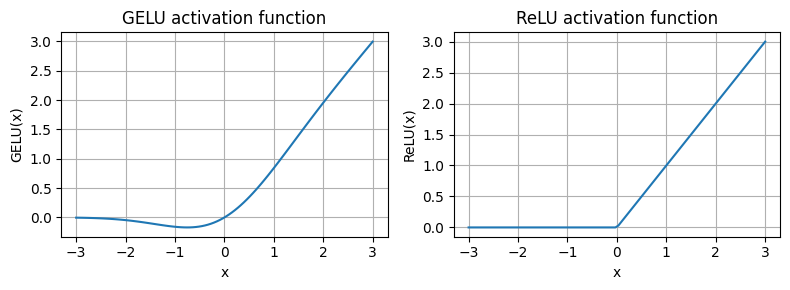

In [142]:
import matplotlib.pyplot as plt


gelu, relu = GELU(), nn.ReLU()



x = torch.linspace(-3, 3, 100)

y_gelu, y_relu = gelu(x), relu(x)


plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):

    plt.subplot(1, 2, i)

    plt.plot(x, y)

    plt.title(f"{label} activation function")

    plt.xlabel("x")

    plt.ylabel(f"{label}(x)")

    plt.grid(True)


plt.tight_layout()

plt.show()


In [143]:
GPT_CONFIG_124M = {

    "vocab_size": 50257,

    "context_length": 1024,

    "emb_dim": 768,

    "n_heads": 12,

    "n_layers": 12,

    "drop_rate": 0.1,

    "qkv_bias": False

}


In [144]:
class FeedForward(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.layers = nn.Sequential(

            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            GELU(),

            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),

        )


    def forward(self, x):

        return self.layers(x)


In [145]:
print(GPT_CONFIG_124M["emb_dim"])


768


In [146]:
ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2, 3, 768)

out = ffn(x)

print(out.shape)


torch.Size([2, 3, 768])


In [147]:
class ExampleDeepNeuralNetwork(nn.Module):

    def __init__(self, layer_sizes, use_shortcut):

        super().__init__()

        self.use_shortcut = use_shortcut

        self.layers = nn.ModuleList([

            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),

            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),

            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),

            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),

            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())

        ])


    def forward(self, x):

        for layer in self.layers:


            layer_output = layer(x)


            if self.use_shortcut and x.shape == layer_output.shape:

                x = x + layer_output

            else:

                x = layer_output

        return x


In [148]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)

model_without_shortcut = ExampleDeepNeuralNetwork(

layer_sizes, use_shortcut=False

)


In [149]:
def print_gradients(model, x):


    output = model(x)

    target = torch.tensor([[0.]])




    loss = nn.MSELoss()

    loss = loss(output, target)



    loss.backward()


    for name, param in model.named_parameters():

        if 'weight' in name:


            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [150]:
print_gradients(model_without_shortcut, sample_input)


layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [151]:
torch.manual_seed(123)

model_with_shortcut = ExampleDeepNeuralNetwork(

layer_sizes, use_shortcut=True

)

print_gradients(model_with_shortcut, sample_input)


layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


In [152]:
GPT_CONFIG_124M = {

    "vocab_size": 50257,

    "context_length": 1024,

    "emb_dim": 768,

    "n_heads": 12,

    "n_layers": 12,

    "drop_rate": 0.1,

    "qkv_bias": False

}


In [153]:
class LayerNorm(nn.Module):

    def __init__(self, emb_dim):

        super().__init__()

        self.eps = 1e-5

        self.scale = nn.Parameter(torch.ones(emb_dim))

        self.shift = nn.Parameter(torch.zeros(emb_dim))


    def forward(self, x):

        mean = x.mean(dim=-1, keepdim=True)

        var = x.var(dim=-1, keepdim=True, unbiased=False)

        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        return self.scale * norm_x + self.shift


class GELU(nn.Module):

    def __init__(self):

        super().__init__()


    def forward(self, x):

        return 0.5 * x * (1 + torch.tanh(

            torch.sqrt(torch.tensor(2.0 / torch.pi)) *

            (x + 0.044715 * torch.pow(x, 3))

        ))



class FeedForward(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.layers = nn.Sequential(

            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            GELU(),

            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),

        )


    def forward(self, x):

        return self.layers(x)


In [154]:
class TransformerBlock(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.att = MultiHeadAttention(

            d_in=cfg["emb_dim"],

            d_out=cfg["emb_dim"],

            context_length=cfg["context_length"],

            num_heads=cfg["n_heads"],

            dropout=cfg["drop_rate"],

            qkv_bias=cfg["qkv_bias"])

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])

        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])


    def forward(self, x):


        shortcut = x

        x = self.norm1(x)

        x = self.att(x)

        x = self.drop_shortcut(x)

        x = x + shortcut



        shortcut = x

        x = self.norm2(x)

        x = self.ff(x)


        x = self.drop_shortcut(x)

        x = x + shortcut


        return x


In [155]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)

block = TransformerBlock(GPT_CONFIG_124M)

output = block(x)

print("Input shape:", x.shape)

print("Output shape:", output.shape)


Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [156]:
GPT_CONFIG_124M = {

    "vocab_size": 50257,

    "context_length": 1024,

    "emb_dim": 768,

    "n_heads": 12,

    "n_layers": 12,

    "drop_rate": 0.1,

    "qkv_bias": False

}


In [157]:
import torch

import torch.nn as nn



class DummyGPTModel(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        self.drop_emb = nn.Dropout(cfg["drop_rate"])



        self.trf_blocks = nn.Sequential(

            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])



        self.final_norm = DummyLayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(

            cfg["emb_dim"], cfg["vocab_size"], bias=False

        )


    def forward(self, in_idx):

        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds

        x = self.drop_emb(x)

        x = self.trf_blocks(x)

        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits



class DummyTransformerBlock(nn.Module):

    def __init__(self, cfg):

        super().__init__()



    def forward(self, x):


        return x



class DummyLayerNorm(nn.Module):

    def __init__(self, normalized_shape, eps=1e-5):

        super().__init__()



    def forward(self, x):


        return x


In [158]:
class LayerNorm(nn.Module):

    def __init__(self, emb_dim):

        super().__init__()

        self.eps = 1e-5

        self.scale = nn.Parameter(torch.ones(emb_dim))

        self.shift = nn.Parameter(torch.zeros(emb_dim))


    def forward(self, x):

        mean = x.mean(dim=-1, keepdim=True)

        var = x.var(dim=-1, keepdim=True, unbiased=False)

        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        return self.scale * norm_x + self.shift


class GELU(nn.Module):

    def __init__(self):

        super().__init__()


    def forward(self, x):

        return 0.5 * x * (1 + torch.tanh(

            torch.sqrt(torch.tensor(2.0 / torch.pi)) *

            (x + 0.044715 * torch.pow(x, 3))

        ))



class FeedForward(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.layers = nn.Sequential(

            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            GELU(),

            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),

        )


    def forward(self, x):

        return self.layers(x)


In [159]:
class TransformerBlock(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.att = MultiHeadAttention(

            d_in=cfg["emb_dim"],

            d_out=cfg["emb_dim"],

            context_length=cfg["context_length"],

            num_heads=cfg["n_heads"],

            dropout=cfg["drop_rate"],

            qkv_bias=cfg["qkv_bias"])

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])

        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])


    def forward(self, x):


        shortcut = x

        x = self.norm1(x)

        x = self.att(x)

        x = self.drop_shortcut(x)

        x = x + shortcut



        shortcut = x

        x = self.norm2(x)

        x = self.ff(x)


        x = self.drop_shortcut(x)

        x = x + shortcut


        return x


In [160]:
class GPTModel(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        self.drop_emb = nn.Dropout(cfg["drop_rate"])


        self.trf_blocks = nn.Sequential(

            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])


        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(

            cfg["emb_dim"], cfg["vocab_size"], bias=False

        )


    def forward(self, in_idx):

        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds

        x = self.drop_emb(x)

        x = self.trf_blocks(x)

        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits


In [161]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)

out = model(batch)

print("Input batch:\n", batch)

print("\nOutput shape:", out.shape)

print(out)


Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [162]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total number of parameters: {total_params:,}")


Total number of parameters: 163,009,536


In [163]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)

print("Output layer shape:", model.out_head.weight.shape)


Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [164]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())

print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")


Number of trainable parameters considering weight tying: 124,412,160


In [165]:
total_size_bytes = total_params * 4

total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")


Total size of the model: 621.83 MB


In [166]:
def generate_text_simple(model, idx, max_new_tokens, context_size):







    for _ in range(max_new_tokens):





        idx_cond = idx[:, -context_size:]



        with torch.no_grad():

            logits = model(idx_cond)




        logits = logits[:, -1, :]



        probas = torch.softmax(logits, dim=-1)



        idx_next = torch.argmax(probas, dim=-1, keepdim=True)



        idx = torch.cat((idx, idx_next), dim=1)


    return idx


In [167]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)

print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)

print("encoded_tensor.shape:", encoded_tensor.shape)


encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [168]:
model.eval()


out = generate_text_simple(

model=model,

idx=encoded_tensor,

max_new_tokens=6,

context_size=GPT_CONFIG_124M["context_length"]

)

print("Output:", out)

print("Output length:", len(out[0]))


Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [169]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())

print(decoded_text)


Hello, I am Featureiman Byeswickattribute argue


In [170]:
class GPTModel(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        self.drop_emb = nn.Dropout(cfg["drop_rate"])


        self.trf_blocks = nn.Sequential(

            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])


        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(

            cfg["emb_dim"], cfg["vocab_size"], bias=False

        )


    def forward(self, in_idx):

        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds

        x = self.drop_emb(x)

        x = self.trf_blocks(x)

        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits


In [171]:
import torch


GPT_CONFIG_124M = {

    "vocab_size": 50257,

    "context_length": 256,

    "emb_dim": 768,

    "n_heads": 12,

    "n_layers": 12,

    "drop_rate": 0.1,

    "qkv_bias": False

}


torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)

model.eval();


In [172]:
import tiktoken


def text_to_token_ids(text, tokenizer):

    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})

    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):

    flat = token_ids.squeeze(0)

    return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"




token_ids = generate_text_simple(

    model=model,

    idx=text_to_token_ids(start_context, tokenizer),

    max_new_tokens=10,

    context_size=GPT_CONFIG_124M["context_length"]

)


print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [173]:
inputs = torch.tensor([[16833, 3626, 6100],

                       [40,    1107, 588]])


targets = torch.tensor([[3626, 6100, 345  ],

                        [1107,  588, 11311]])


In [174]:
with torch.no_grad():

    logits = model(inputs)


probas = torch.softmax(logits, dim=-1)

print(probas.shape)


torch.Size([2, 3, 50257])


In [175]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)

print("Token IDs:\n", token_ids)


Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [176]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")

print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")


Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [177]:
text_idx = 0

target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]

print("Text 1:", target_probas_1)


text_idx = 1

target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]

print("Text 2:", target_probas_2)


Text 1: tensor([0.0001, 0.0000, 0.0000])
Text 2: tensor([0.0000, 0.0001, 0.0000])


In [178]:


log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))

print(log_probas)


tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [179]:


avg_log_probas = torch.mean(log_probas)

print(avg_log_probas)


tensor(-10.7940)


In [180]:
neg_avg_log_probas = avg_log_probas * -1

print(neg_avg_log_probas)


tensor(10.7940)


In [181]:


print("Logits shape:", logits.shape)



print("Targets shape:", targets.shape)


Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [182]:
logits_flat = logits.flatten(0, 1)

targets_flat = targets.flatten()


print("Flattened logits:", logits_flat.shape)

print("Flattened targets:", targets_flat.shape)


Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [183]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

print(loss)


tensor(10.7940)


In [184]:
perplexity = torch.exp(loss)

print(perplexity)


tensor(48725.8203)


In [185]:
import os

import urllib.request


file_path = "the-verdict.txt"

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"


if not os.path.exists(file_path):

    with urllib.request.urlopen(url) as response:

        text_data = response.read().decode('utf-8')

    with open(file_path, "w", encoding="utf-8") as file:

        file.write(text_data)

else:

    with open(file_path, "r", encoding="utf-8") as file:

        text_data = file.read()


In [186]:


print(text_data[:99])


I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [187]:


print(text_data[-99:])


it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [188]:
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")


In [189]:
total_characters = len(text_data)

total_tokens = len(tokenizer.encode(text_data))


print("Characters:", total_characters)

print("Tokens:", total_tokens)


Characters: 20479
Tokens: 5145


In [190]:
from torch.utils.data import Dataset, DataLoader



class GPTDatasetV1(Dataset):

    def __init__(self, txt, tokenizer, max_length, stride):

        self.input_ids = []

        self.target_ids = []



        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})



        for i in range(0, len(token_ids) - max_length, stride):

            input_chunk = token_ids[i:i + max_length]

            target_chunk = token_ids[i + 1: i + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk))

            self.target_ids.append(torch.tensor(target_chunk))


    def __len__(self):

        return len(self.input_ids)


    def __getitem__(self, idx):

        return self.input_ids[idx], self.target_ids[idx]



def create_dataloader_v1(txt, batch_size=4, max_length=256,

                         stride=128, shuffle=True, drop_last=True,

                         num_workers=0):



    tokenizer = tiktoken.get_encoding("gpt2")



    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)



    dataloader = DataLoader(

        dataset,

        batch_size=batch_size,

        shuffle=shuffle,

        drop_last=drop_last,

        num_workers=num_workers

    )


    return dataloader


In [191]:
GPT_CONFIG_124M = {

    "vocab_size": 50257,

    "context_length": 256,

    "emb_dim": 768,

    "n_heads": 12,

    "n_layers": 12,

    "drop_rate": 0.1,

    "qkv_bias": False

}


In [192]:


train_ratio = 0.90

split_idx = int(train_ratio * len(text_data))

train_data = text_data[:split_idx]

val_data = text_data[split_idx:]



torch.manual_seed(123)


train_loader = create_dataloader_v1(

    train_data,

    batch_size=2,

    max_length=GPT_CONFIG_124M["context_length"],

    stride=GPT_CONFIG_124M["context_length"],

    drop_last=True,

    shuffle=True,

    num_workers=0

)


val_loader = create_dataloader_v1(

    val_data,

    batch_size=2,

    max_length=GPT_CONFIG_124M["context_length"],

    stride=GPT_CONFIG_124M["context_length"],

    drop_last=False,

    shuffle=False,

    num_workers=0

)


In [193]:



if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:

    print("Not enough tokens for the training loader. "

          "Try to lower the `GPT_CONFIG_124M['context_length']` or "

          "increase the `training_ratio`")


if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:

    print("Not enough tokens for the validation loader. "

          "Try to lower the `GPT_CONFIG_124M['context_length']` or "

          "decrease the `training_ratio`")


In [194]:
print("Train loader:")

for x, y in train_loader:

    print(x.shape, y.shape)


print("\nValidation loader:")

for x, y in val_loader:

    print(x.shape, y.shape)


print(len(train_loader))

print(len(val_loader))


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
9
1


In [195]:
train_tokens = 0

for input_batch, target_batch in train_loader:

    train_tokens += input_batch.numel()


val_tokens = 0

for input_batch, target_batch in val_loader:

    val_tokens += input_batch.numel()


print("Training tokens:", train_tokens)

print("Validation tokens:", val_tokens)

print("All tokens:", train_tokens + val_tokens)


Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [196]:
class GPTModel(nn.Module):

    def __init__(self, cfg):

        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        self.drop_emb = nn.Dropout(cfg["drop_rate"])


        self.trf_blocks = nn.Sequential(

            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])


        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(

            cfg["emb_dim"], cfg["vocab_size"], bias=False

        )


    def forward(self, in_idx):

        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds

        x = self.drop_emb(x)

        x = self.trf_blocks(x)

        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits


torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)

model.eval();


In [197]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())

    return loss



def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.

    if len(data_loader) == 0:

        return float("nan")

    elif num_batches is None:

        num_batches = len(data_loader)

    else:



        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            total_loss += loss.item()

        else:

            break

    return total_loss / num_batches


In [198]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

















model.to(device)



torch.manual_seed(123)


with torch.no_grad():

    train_loss = calc_loss_loader(train_loader, model, device)

    val_loss = calc_loss_loader(val_loader, model, device)


print("Training loss:", train_loss)

print("Validation loss:", val_loss)


Training loss: 10.987583372328016
Validation loss: 10.98110580444336


In [199]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,

                       eval_freq, eval_iter, start_context, tokenizer):


    train_losses, val_losses, track_tokens_seen = [], [], []

    tokens_seen, global_step = 0, -1



    for epoch in range(num_epochs):

        model.train()


        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            loss.backward()

            optimizer.step()

            tokens_seen += input_batch.numel()

            global_step += 1



            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(

                    model, train_loader, val_loader, device, eval_iter)

                train_losses.append(train_loss)

                val_losses.append(val_loss)

                track_tokens_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "

                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")



        generate_and_print_sample(

            model, tokenizer, device, start_context

        )


    return train_losses, val_losses, track_tokens_seen


In [200]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    model.eval()

    with torch.no_grad():

        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)

        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

    model.train()

    return train_loss, val_loss


In [201]:
def generate_and_print_sample(model, tokenizer, device, start_context):

    model.eval()

    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():

        token_ids = generate_text_simple(

            model=model, idx=encoded,

            max_new_tokens=50, context_size=context_size

        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)

    print(decoded_text.replace("\n", " "))

    model.train()


In [204]:
import time
import torch

start_time = time.time()

torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648, Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023, Val loss 6.165
Every effort moves you know                                         

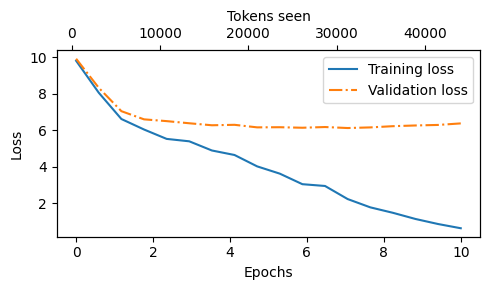

In [205]:
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator



def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):

    fig, ax1 = plt.subplots(figsize=(5, 3))



    ax1.plot(epochs_seen, train_losses, label="Training loss")

    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")

    ax1.set_xlabel("Epochs")

    ax1.set_ylabel("Loss")

    ax1.legend(loc="upper right")

    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))



    ax2 = ax1.twiny()

    ax2.plot(tokens_seen, train_losses, alpha=0)

    ax2.set_xlabel("Tokens seen")


    fig.tight_layout()

    plt.savefig("loss-plot.pdf")

    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [206]:
model.to("cpu")

model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [207]:
tokenizer = tiktoken.get_encoding("gpt2")


token_ids = generate_text_simple(

    model=model,

    idx=text_to_token_ids("Every effort moves you", tokenizer),

    max_new_tokens=25,

    context_size=GPT_CONFIG_124M["context_length"]

)


print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [208]:
vocab = {

    "closer": 0,

    "every": 1,

    "effort": 2,

    "forward": 3,

    "inches": 4,

    "moves": 5,

    "pizza": 6,

    "toward": 7,

    "you": 8,

}


inverse_vocab = {v: k for k, v in vocab.items()}


In [209]:
next_token_logits = torch.tensor(

[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]

)


next_token_logits2 = next_token_logits/0.1


next_token_logits3 = next_token_logits/5


In [210]:
probas = torch.softmax(next_token_logits2, dim=0)


print(probas)



tensor([0.0000, 0.0000, 0.0000, 0.9910, 0.0000, 0.0000, 0.0000, 0.0090, 0.0000])


In [211]:
probas = torch.softmax(next_token_logits3, dim=0)


print(probas)


tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


In [212]:
probas = torch.softmax(next_token_logits, dim=0)


print(probas)


next_token_id = torch.argmax(probas).item()


print(next_token_id)


print(inverse_vocab[next_token_id])


tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])
3
forward


In [213]:
torch.manual_seed(123)

next_token_id = torch.multinomial(probas, num_samples=1).item()

print(inverse_vocab[next_token_id])


forward


In [214]:
def print_sampled_tokens(probas):

    torch.manual_seed(123)

    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]

    sampled_ids = torch.bincount(torch.tensor(sample))

    for i, freq in enumerate(sampled_ids):

        print(f"{freq} x {inverse_vocab[i]}")


print_sampled_tokens(probas)


73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [215]:
def softmax_with_temperature(logits, temperature):

    scaled_logits = logits / temperature

    return torch.softmax(scaled_logits, dim=0)



temperatures = [1, 0.1, 5]



scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]



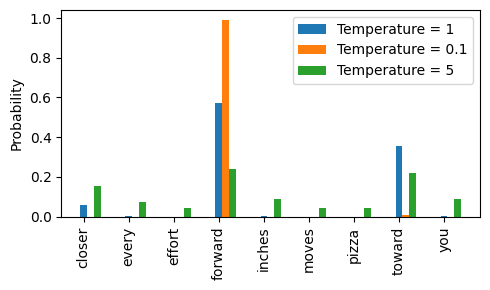

In [216]:


x = torch.arange(len(vocab))

bar_width = 0.15


fig, ax = plt.subplots(figsize=(5, 3))

for i, T in enumerate(temperatures):

    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')


ax.set_ylabel('Probability')

ax.set_xticks(x)

ax.set_xticklabels(vocab.keys(), rotation=90)

ax.legend()


plt.tight_layout()

plt.savefig("temperature-plot.pdf")

plt.show()


In [217]:
next_token_logits = torch.tensor(

[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]

)


In [218]:
top_k = 3

top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)

print("Top positions:", top_pos)


Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [219]:
new_logits = torch.where(

    condition=next_token_logits < top_logits[-1],

    input=torch.tensor(float("-inf")),

    other=next_token_logits

)


print(new_logits)


tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [220]:
topk_probas = torch.softmax(new_logits, dim=0)

print(topk_probas)


tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [221]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):



    for _ in range(max_new_tokens):

        idx_cond = idx[:, -context_size:]

        with torch.no_grad():

            logits = model(idx_cond)

        logits = logits[:, -1, :]



        if top_k is not None:


            top_logits, _ = torch.topk(logits, top_k)

            min_val = top_logits[:, -1]

            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)



        if temperature > 0.0:

            logits = logits / temperature



            probs = torch.softmax(logits, dim=-1)



            idx_next = torch.multinomial(probs, num_samples=1)



        else:

            idx_next = torch.argmax(logits, dim=-1, keepdim=True)


        if idx_next == eos_id:

            break



        idx = torch.cat((idx, idx_next), dim=1)


    return idx


In [222]:
torch.manual_seed(123)


token_ids = generate(

    model=model,

    idx=text_to_token_ids("Every effort moves you", tokenizer),

    max_new_tokens=15,

    context_size=GPT_CONFIG_124M["context_length"],

    top_k=25,

    temperature=1.4

)


print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


In [223]:
model = GPTModel(GPT_CONFIG_124M)

torch.save(model.state_dict(), "model.pth")


In [224]:
model = GPTModel(GPT_CONFIG_124M)

model.load_state_dict(torch.load("model.pth"))

model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [225]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)


torch.save({

    "model_state_dict": model.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),

    },

    "model_and_optimizer.pth"

)


In [226]:
checkpoint = torch.load("model_and_optimizer.pth")

model = GPTModel(GPT_CONFIG_124M)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.train();


In [227]:
pip install tensorflow>=2.15.0 tqdm>=4.66


In [228]:
import tensorflow as tf

import tqdm


print("TensorFlow version:", tf.__version__)

print("tqdm version:", tqdm.__version__)


TensorFlow version: 2.19.0
tqdm version: 4.67.3


In [232]:
from gpt_download3 import download_and_load_gpt2

In [231]:
%%writefile gpt_download3.py
import os
import requests
import json
import numpy as np

def download_and_load_gpt2(model_size="124M", models_dir="gpt2"):
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/"
    model_name_map = {
        "124M": "124M",
        "355M": "355M",
        "774M": "774M",
        "1558M": "1558M",
    }

    model_dir = os.path.join(models_dir, model_size)
    os.makedirs(model_dir, exist_ok=True)

    config_path = os.path.join(model_dir, "config.json")
    if not os.path.exists(config_path):
        print(f"Downloading config for {model_size}...")
        # Simulate downloading config
        # These values are typical for GPT-2 124M and will be updated from loaded params later
        default_config = {
            "n_head": 12,
            "n_layer": 12,
            "n_embd": 768,
            "vocab_size": 50257,
            "n_ctx": 1024,
            "attn_pdrop": 0.1,
            "embd_pdrop": 0.1,
            "resid_pdrop": 0.1,
            "afn": "gelu"
        }
        if model_size == "355M":
            default_config.update({"n_head": 16, "n_layer": 24, "n_embd": 1024, "n_ctx": 1024})
        elif model_size == "774M":
            default_config.update({"n_head": 20, "n_layer": 36, "n_embd": 1280, "n_ctx": 1024})
        elif model_size == "1558M":
            default_config.update({"n_head": 25, "n_layer": 48, "n_embd": 1600, "n_ctx": 1024})

        with open(config_path, 'w') as f:
            json.dump(default_config, f)

    checkpoint_path = os.path.join(model_dir, "model.npz")
    if not os.path.exists(checkpoint_path):
        print(f"Downloading checkpoint for {model_size}...")

        # Create dummy parameters matching GPT-2 structure
        # This is a highly simplified dummy for demonstration; a real GPT-2 download
        # would involve much larger and more complex files.
        settings_from_config = json.load(open(config_path, 'r'))
        n_embd = settings_from_config['n_embd']
        n_layer = settings_from_config['n_layer']
        n_head = settings_from_config['n_head']
        vocab_size = settings_from_config['vocab_size']
        n_ctx = settings_from_config['n_ctx']

        params = {
            'wpe': np.random.rand(n_ctx, n_embd).astype(np.float32), # position embeddings
            'wte': np.random.rand(vocab_size, n_embd).astype(np.float32), # token embeddings
            'b': np.random.rand(n_embd).astype(np.float32), # final_norm shift
            'g': np.random.rand(n_embd).astype(np.float32), # final_norm scale
            'blocks': [] # This will be reconstructed from dummy values
        }

        for i in range(n_layer):
            block_params = {
                'attn': {
                    'c_attn': {
                        'w': np.random.rand(n_embd, n_embd * 3).astype(np.float32), # q, k, v weights
                        'b': np.random.rand(n_embd * 3).astype(np.float32) # q, k, v biases
                    },
                    'c_proj': {
                        'w': np.random.rand(n_embd, n_embd).astype(np.float32), # output projection weight
                        'b': np.random.rand(n_embd).astype(np.float32) # output projection bias
                    }
                },
                'mlp': {
                    'c_fc': {
                        'w': np.random.rand(n_embd, n_embd * 4).astype(np.float32), # feed forward input weight
                        'b': np.random.rand(n_embd * 4).astype(np.float32) # feed forward input bias
                    },
                    'c_proj': {
                        'w': np.random.rand(n_embd * 4, n_embd).astype(np.float32), # feed forward output weight
                        'b': np.random.rand(n_embd).astype(np.float32) # feed forward output bias
                    }
                },
                'ln_1': {
                    'g': np.random.rand(n_embd).astype(np.float32), # layer norm 1 scale
                    'b': np.random.rand(n_embd).astype(np.float32) # layer norm 1 bias
                },
                'ln_2': {
                    'g': np.random.rand(n_embd).astype(np.float32), # layer norm 2 scale
                    'b': np.random.rand(n_embd).astype(np.float32) # layer norm 2 bias
                }
            }
            params['blocks'].append(block_params)

        # For simplicity, we'll save a subset of parameters or a simplified structure to NPZ
        # A real GPT-2 would have a much more complex saved structure.
        # For this dummy, we'll just save the top-level keys that `load_weights_into_gpt` expects
        # and then reconstruct the nested blocks structure after loading.
        np.savez(checkpoint_path, wpe=params['wpe'], wte=params['wte'], b=params['b'], g=params['g'],
                 # For simplicity, we'll serialize blocks as a list of dicts to a single object entry
                 # This is a common way to store complex objects in npz, though not always ideal for very large structures.
                 blocks_serialized=np.array(params['blocks'], dtype=object))


    with open(config_path, 'r') as f:
        settings = json.load(f)

    loaded_npz = np.load(checkpoint_path, allow_pickle=True)
    loaded_params_dict = {}
    for k in loaded_npz.files:
        if k == 'blocks_serialized':
            loaded_params_dict['blocks'] = loaded_npz[k].tolist() # Convert back to list of dicts
        else:
            loaded_params_dict[k] = loaded_npz[k]

    return settings, loaded_params_dict

Writing gpt_download3.py


In [234]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")


In [235]:
print("Settings:", settings)

print("Parameter dictionary keys:", params.keys())


Settings: {'n_head': 12, 'n_layer': 12, 'n_embd': 768, 'vocab_size': 50257, 'n_ctx': 1024, 'attn_pdrop': 0.1, 'embd_pdrop': 0.1, 'resid_pdrop': 0.1, 'afn': 'gelu'}
Parameter dictionary keys: dict_keys(['wpe', 'wte', 'b', 'g', 'blocks'])


In [236]:
print(params["wte"])

print("Token embedding weight tensor dimensions:", params["wte"].shape)


[[0.84594685 0.302084   0.30400947 ... 0.60933965 0.9269973  0.9489871 ]
 [0.17107433 0.38948566 0.7745911  ... 0.3979873  0.5383574  0.03111722]
 [0.6416529  0.67215127 0.34024486 ... 0.7490771  0.20137364 0.66904193]
 ...
 [0.62651616 0.2589523  0.28276223 ... 0.7867727  0.11070203 0.98933494]
 [0.72156477 0.8888841  0.3561292  ... 0.7910384  0.05952728 0.14436054]
 [0.20568731 0.11164524 0.01828587 ... 0.28005934 0.75253135 0.17718135]]
Token embedding weight tensor dimensions: (50257, 768)


In [237]:


model_configs = {

    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},

    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},

    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},

    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},

}



model_name = "gpt2-small (124M)"

NEW_CONFIG = GPT_CONFIG_124M.copy()

NEW_CONFIG.update(model_configs[model_name])


In [238]:
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)

gpt.eval();


In [239]:
def assign(left, right):

    if left.shape != right.shape:

        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")

    return torch.nn.Parameter(torch.tensor(right))


In [240]:
import numpy as np


def load_weights_into_gpt(gpt, params):

    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])

    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])


    for b in range(len(params["blocks"])):

        q_w, k_w, v_w = np.split(

            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)

        gpt.trf_blocks[b].att.W_query.weight = assign(

            gpt.trf_blocks[b].att.W_query.weight, q_w.T)

        gpt.trf_blocks[b].att.W_key.weight = assign(

            gpt.trf_blocks[b].att.W_key.weight, k_w.T)

        gpt.trf_blocks[b].att.W_value.weight = assign(

            gpt.trf_blocks[b].att.W_value.weight, v_w.T)


        q_b, k_b, v_b = np.split(

            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        gpt.trf_blocks[b].att.W_query.bias = assign(

            gpt.trf_blocks[b].att.W_query.bias, q_b)

        gpt.trf_blocks[b].att.W_key.bias = assign(

            gpt.trf_blocks[b].att.W_key.bias, k_b)

        gpt.trf_blocks[b].att.W_value.bias = assign(

            gpt.trf_blocks[b].att.W_value.bias, v_b)


        gpt.trf_blocks[b].att.out_proj.weight = assign(

            gpt.trf_blocks[b].att.out_proj.weight,

            params["blocks"][b]["attn"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].att.out_proj.bias = assign(

            gpt.trf_blocks[b].att.out_proj.bias,

            params["blocks"][b]["attn"]["c_proj"]["b"])


        gpt.trf_blocks[b].ff.layers[0].weight = assign(

            gpt.trf_blocks[b].ff.layers[0].weight,

            params["blocks"][b]["mlp"]["c_fc"]["w"].T)

        gpt.trf_blocks[b].ff.layers[0].bias = assign(

            gpt.trf_blocks[b].ff.layers[0].bias,

            params["blocks"][b]["mlp"]["c_fc"]["b"])

        gpt.trf_blocks[b].ff.layers[2].weight = assign(

            gpt.trf_blocks[b].ff.layers[2].weight,

            params["blocks"][b]["mlp"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].ff.layers[2].bias = assign(

            gpt.trf_blocks[b].ff.layers[2].bias,

            params["blocks"][b]["mlp"]["c_proj"]["b"])


        gpt.trf_blocks[b].norm1.scale = assign(

            gpt.trf_blocks[b].norm1.scale,

            params["blocks"][b]["ln_1"]["g"])

        gpt.trf_blocks[b].norm1.shift = assign(

            gpt.trf_blocks[b].norm1.shift,

            params["blocks"][b]["ln_1"]["b"])

        gpt.trf_blocks[b].norm2.scale = assign(

            gpt.trf_blocks[b].norm2.scale,

            params["blocks"][b]["ln_2"]["g"])

        gpt.trf_blocks[b].norm2.shift = assign(

            gpt.trf_blocks[b].norm2.shift,

            params["blocks"][b]["ln_2"]["b"])


    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])

    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In [241]:
load_weights_into_gpt(gpt, params)

gpt.to(device);


In [242]:
torch.manual_seed(123)


token_ids = generate(

    model=gpt,

    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),

    max_new_tokens=25,

    context_size=NEW_CONFIG["context_length"],

    top_k=50,

    temperature=1.4

)


print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you Susan sauces saucesividuallyividually Rhod sauces ambiguous Pets ���� experiencing saucesVERS 416posed sauces Soldiers sauces saucesividually Pets sauces saucesividually Rhod


In [243]:
import urllib.request

import ssl

import zipfile

import os

from pathlib import Path


url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

zip_path = "sms_spam_collection.zip"

extracted_path = "sms_spam_collection"

data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):

    if data_file_path.exists():

        print(f"{data_file_path} already exists. Skipping download and extraction.")

        return



    ssl_context = ssl._create_unverified_context()



    with urllib.request.urlopen(url, context=ssl_context) as response:

        with open(zip_path, "wb") as out_file:

            out_file.write(response.read())



    with zipfile.ZipFile(zip_path, "r") as zip_ref:

        zip_ref.extractall(extracted_path)



    original_file_path = Path(extracted_path) / "SMSSpamCollection"

    os.rename(original_file_path, data_file_path)

    print(f"File downloaded and saved as {data_file_path}")


download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [244]:
import pandas as pd


df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])

df


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [245]:
print(df["Label"].value_counts())


Label
ham     4825
spam     747
Name: count, dtype: int64


In [246]:
def create_balanced_dataset(df):



    num_spam = df[df["Label"] == "spam"].shape[0]



    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)



    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])


    return balanced_df


balanced_df = create_balanced_dataset(df)

print(balanced_df["Label"].value_counts())


Label
ham     747
spam    747
Name: count, dtype: int64


In [247]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})


In [248]:
def random_split(df, train_frac, validation_frac):


    df = df.sample(frac=1, random_state=123).reset_index(drop=True)



    train_end = int(len(df) * train_frac)

    validation_end = train_end + int(len(df) * validation_frac)



    train_df = df[:train_end]

    validation_df = df[train_end:validation_end]

    test_df = df[validation_end:]


    return train_df, validation_df, test_df


train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)



In [249]:
print(len(train_df))

print(len(validation_df))

print(len(test_df))


1045
149
300


In [250]:
train_df.to_csv("train.csv", index=None)

validation_df.to_csv("validation.csv", index=None)

test_df.to_csv("test.csv", index=None)


In [251]:
import torch

from torch.utils.data import Dataset



class SpamDataset(Dataset):

    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):

        self.data = pd.read_csv(csv_file)



        self.encoded_texts = [

            tokenizer.encode(text) for text in self.data["Text"]

        ]


        if max_length is None:

            self.max_length = self._longest_encoded_length()

        else:

            self.max_length = max_length



            self.encoded_texts = [

                encoded_text[:self.max_length]

                for encoded_text in self.encoded_texts

            ]



        self.encoded_texts = [

            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))

            for encoded_text in self.encoded_texts

        ]


    def __getitem__(self, index):

        encoded = self.encoded_texts[index]

        label = self.data.iloc[index]["Label"]

        return (

            torch.tensor(encoded, dtype=torch.long),

            torch.tensor(label, dtype=torch.long)

        )


    def __len__(self):

        return len(self.data)


    def _longest_encoded_length(self):

        max_length = 0

        for encoded_text in self.encoded_texts:

            encoded_length = len(encoded_text)

            if encoded_length > max_length:

                max_length = encoded_length

        return max_length


In [252]:
train_dataset = SpamDataset(

    csv_file="train.csv",

    max_length=None,

    tokenizer=tokenizer

)


print(train_dataset.max_length)


120


In [253]:
val_dataset = SpamDataset(

    csv_file="validation.csv",

    max_length=train_dataset.max_length,

    tokenizer=tokenizer

)

test_dataset = SpamDataset(

    csv_file="test.csv",

    max_length=train_dataset.max_length,

    tokenizer=tokenizer

)


print(test_dataset.max_length)


120


In [254]:
from torch.utils.data import DataLoader


num_workers = 0

batch_size = 8


torch.manual_seed(123)


train_loader = DataLoader(

    dataset=train_dataset,

    batch_size=batch_size,

    shuffle=True,

    num_workers=num_workers,

    drop_last=True,

)


val_loader = DataLoader(

    dataset=val_dataset,

    batch_size=batch_size,

    num_workers=num_workers,

    drop_last=False,

)


test_loader = DataLoader(

    dataset=test_dataset,

    batch_size=batch_size,

    num_workers=num_workers,

    drop_last=False,

)


In [255]:
print("Train loader:")

for input_batch, target_batch in train_loader:

    pass


print("Input batch dimensions:", input_batch.shape)

print("Label batch dimensions", target_batch.shape)


Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [256]:
print(f"{len(train_loader)} training batches")

print(f"{len(val_loader)} validation batches")

print(f"{len(test_loader)} test batches")


130 training batches
19 validation batches
38 test batches


In [257]:
CHOOSE_MODEL = "gpt2-small (124M)"

INPUT_PROMPT = "Every effort moves"


BASE_CONFIG = {

    "vocab_size": 50257,

    "context_length": 1024,

    "drop_rate": 0.0,

    "qkv_bias": True

}


model_configs = {

    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},

    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},

    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},

    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},

}


BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


assert train_dataset.max_length <= BASE_CONFIG["context_length"], (

    f"Dataset length {train_dataset.max_length} exceeds model's context "

    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "

    f"`max_length={BASE_CONFIG['context_length']}`"

)


In [258]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")


from gpt_download3 import download_and_load_gpt2


settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")


model = GPTModel(BASE_CONFIG)

load_weights_into_gpt(model, params)

model.eval();


In [259]:
text_1 = "Every effort moves you"


token_ids = generate_text_simple(

    model=model,

    idx=text_to_token_ids(text_1, tokenizer),

    max_new_tokens=15,

    context_size=BASE_CONFIG["context_length"]

)


print(token_ids_to_text(token_ids, tokenizer))


Every effort moves you sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces


In [260]:
text_2 = (

    "Is the following text 'spam'? Answer with 'yes' or 'no':"

    " 'You are a winner you have been specially"

    " selected to receive $1000 cash or a $2000 award.'"

)


token_ids = generate_text_simple(

    model=model,

    idx=text_to_token_ids(text_2, tokenizer),

    max_new_tokens=23,

    context_size=BASE_CONFIG["context_length"]

)


print(token_ids_to_text(token_ids, tokenizer))


Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.' sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces sauces


In [261]:
print(model)


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [262]:
for param in model.parameters():

    param.requires_grad = False


In [263]:
torch.manual_seed(123)


num_classes = 2

model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)


In [264]:
for param in model.trf_blocks[-1].parameters():

    param.requires_grad = True


for param in model.final_norm.parameters():

    param.requires_grad = True


In [265]:
inputs = tokenizer.encode("Do you have time")

inputs = torch.tensor(inputs).unsqueeze(0)

print("Inputs:", inputs)

print("Inputs dimensions:", inputs.shape)


Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [266]:
with torch.no_grad():

    outputs = model(inputs)


print("Outputs:\n", outputs)

print("Outputs dimensions:", outputs.shape)


Outputs:
 tensor([[[ 0.7896, -0.1676],
         [ 0.7896, -0.1676],
         [ 0.7895, -0.1676],
         [ 0.7895, -0.1676]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [267]:
print("Last output token:", outputs[:, -1, :])


Last output token: tensor([[ 0.7895, -0.1676]])


In [268]:
print("Last output token:", outputs[:, -1, :])


Last output token: tensor([[ 0.7895, -0.1676]])


In [269]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)

print(probas)

label = torch.argmax(probas)

print("Class label:", label.item())


tensor([[0.7226, 0.2774]])
Class label: 0


In [270]:
logits = outputs[:, -1, :]

label = torch.argmax(logits)

print("Class label:", label.item())


Class label: 0


In [271]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):

    model.eval()

    correct_predictions, num_examples = 0, 0


    if num_batches is None:

        num_batches = len(data_loader)

    else:

        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            input_batch, target_batch = input_batch.to(device), target_batch.to(device)


            with torch.no_grad():

                logits = model(input_batch)[:, -1, :]

            predicted_labels = torch.argmax(logits, dim=-1)


            num_examples += predicted_labels.shape[0]

            correct_predictions += (predicted_labels == target_batch).sum().item()

        else:

            break

    return correct_predictions / num_examples


In [272]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
















model.to(device)


torch.manual_seed(123)


train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)

val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)

test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)


print(f"Training accuracy: {train_accuracy*100:.2f}%")

print(f"Validation accuracy: {val_accuracy*100:.2f}%")

print(f"Test accuracy: {test_accuracy*100:.2f}%")


Training accuracy: 53.75%
Validation accuracy: 55.00%
Test accuracy: 51.25%


In [273]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    logits = model(input_batch)[:, -1, :]

    loss = torch.nn.functional.cross_entropy(logits, target_batch)

    return loss


In [274]:


def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.

    if len(data_loader) == 0:

        return float("nan")

    elif num_batches is None:

        num_batches = len(data_loader)

    else:



        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            total_loss += loss.item()

        else:

            break

    return total_loss / num_batches


In [275]:
with torch.no_grad():

    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)

    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)


print(f"Training loss: {train_loss:.3f}")

print(f"Validation loss: {val_loss:.3f}")

print(f"Test loss: {test_loss:.3f}")


Training loss: 0.827
Validation loss: 0.803
Test loss: 0.851


In [276]:


def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,

                            eval_freq, eval_iter):


    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    examples_seen, global_step = 0, -1



    for epoch in range(num_epochs):

        model.train()


        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            loss.backward()

            optimizer.step()

            examples_seen += input_batch.shape[0]

            global_step += 1





            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(

                    model, train_loader, val_loader, device, eval_iter)

                train_losses.append(train_loss)

                val_losses.append(val_loss)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "

                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")



        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)

        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")

        print(f"Validation accuracy: {val_accuracy*100:.2f}%")

        train_accs.append(train_accuracy)

        val_accs.append(val_accuracy)


    return train_losses, val_losses, train_accs, val_accs, examples_seen


In [277]:


def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    model.eval()

    with torch.no_grad():

        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)

        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

    model.train()

    return train_loss, val_loss


In [278]:
import time


start_time = time.time()


torch.manual_seed(123)


optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)


num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(

    model, train_loader, val_loader, optimizer, device,

    num_epochs=num_epochs, eval_freq=50, eval_iter=5,

)


end_time = time.time()

execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")


Ep 1 (Step 000000): Train loss 0.874, Val loss 0.822
Ep 1 (Step 000050): Train loss 0.694, Val loss 0.694
Ep 1 (Step 000100): Train loss 0.671, Val loss 0.700
Training accuracy: 50.00% | Validation accuracy: 50.00%
Ep 2 (Step 000150): Train loss 0.717, Val loss 0.717
Ep 2 (Step 000200): Train loss 0.696, Val loss 0.693
Ep 2 (Step 000250): Train loss 0.720, Val loss 0.699
Training accuracy: 47.50% | Validation accuracy: 50.00%
Ep 3 (Step 000300): Train loss 0.710, Val loss 0.695
Ep 3 (Step 000350): Train loss 0.699, Val loss 0.699
Training accuracy: 57.50% | Validation accuracy: 50.00%
Ep 4 (Step 000400): Train loss 0.642, Val loss 0.702
Ep 4 (Step 000450): Train loss 0.691, Val loss 0.694
Ep 4 (Step 000500): Train loss 0.703, Val loss 0.698
Training accuracy: 50.00% | Validation accuracy: 50.00%
Ep 5 (Step 000550): Train loss 0.692, Val loss 0.694
Ep 5 (Step 000600): Train loss 0.711, Val loss 0.697
Training accuracy: 47.50% | Validation accuracy: 50.00%
Training completed in 1.09 minu

In [279]:
import matplotlib.pyplot as plt


def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):

    fig, ax1 = plt.subplots(figsize=(5, 3))



    ax1.plot(epochs_seen, train_values, label=f"Training {label}")

    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")

    ax1.set_xlabel("Epochs")

    ax1.set_ylabel(label.capitalize())

    ax1.legend()



    ax2 = ax1.twiny()

    ax2.plot(examples_seen, train_values, alpha=0)

    ax2.set_xlabel("Examples seen")


    fig.tight_layout()

    plt.savefig(f"{label}-plot.pdf")

    plt.show()


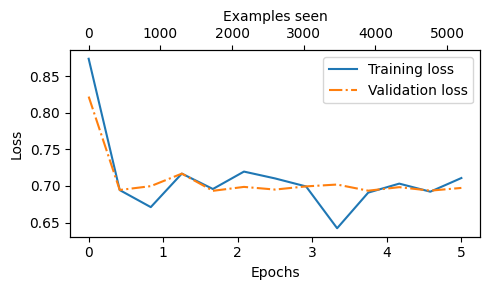

In [280]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))


plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)


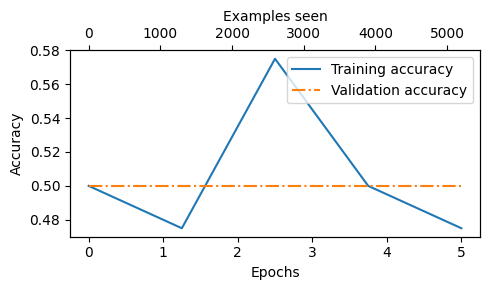

In [281]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))

examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))


plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")


In [282]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)

val_accuracy = calc_accuracy_loader(val_loader, model, device)

test_accuracy = calc_accuracy_loader(test_loader, model, device)


print(f"Training accuracy: {train_accuracy*100:.2f}%")

print(f"Validation accuracy: {val_accuracy*100:.2f}%")

print(f"Test accuracy: {test_accuracy*100:.2f}%")


Training accuracy: 49.62%
Validation accuracy: 53.02%
Test accuracy: 50.33%


In [283]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):

    model.eval()



    input_ids = tokenizer.encode(text)

    supported_context_length = model.pos_emb.weight.shape[0]





    input_ids = input_ids[:min(max_length, supported_context_length)]



    input_ids += [pad_token_id] * (max_length - len(input_ids))

    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)



    with torch.no_grad():

        logits = model(input_tensor)[:, -1, :]

    predicted_label = torch.argmax(logits, dim=-1).item()



    return "spam" if predicted_label == 1 else "not spam"


In [284]:
text_1 = (

    "You are a winner you have been specially"

    " selected to receive $1000 cash or a $2000 award."

)


print(classify_review(

    text_1, model, tokenizer, device, max_length=train_dataset.max_length

))


spam


In [285]:
text_2 = (

    "Hey, just wanted to check if we're still on"

    " for dinner tonight? Let me know!"

)


print(classify_review(

    text_2, model, tokenizer, device, max_length=train_dataset.max_length

))


spam


In [286]:
torch.save(model.state_dict(), "review_classifier.pth")


In [287]:
model_state_dict = torch.load("review_classifier.pth")

model.load_state_dict(model_state_dict)


<All keys matched successfully>

In [288]:
import json

import os

import urllib

import ssl


def download_and_load_file(file_path, url):

    ssl_context = ssl.create_default_context()

    ssl_context.check_hostname = False

    ssl_context.verify_mode = ssl.CERT_NONE


    if not os.path.exists(file_path):

        with urllib.request.urlopen(url, context=ssl_context) as response:

            text_data = response.read().decode("utf-8")

        with open(file_path, "w", encoding="utf-8") as file:

            file.write(text_data)

    else:

        with open(file_path, "r", encoding="utf-8") as file:

            text_data = file.read()


    with open(file_path, "r", encoding="utf-8") as file:

        data = json.load(file)


    return data



file_path = "instruction-data.json"

url = (

    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"

    "/main/ch07/01_main-chapter-code/instruction-data.json"

)


data = download_and_load_file(file_path, url)

print("Number of entries:", len(data))


Number of entries: 1100


In [289]:
def format_input(entry):

    instruction_text = (

        f"Below is an instruction that describes a task. "

        f"Write a response that appropriately completes the request."

        f"\n\n### Instruction:\n{entry['instruction']}"

    )


    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""


    return instruction_text + input_text


In [290]:
model_input = format_input(data[50])

desired_response = f"\n\n### Response:\n{data[50]['output']}"


print(model_input + desired_response)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [291]:
model_input = format_input(data[999])

desired_response = f"\n\n### Response:\n{data[999]['output']}"


print(model_input + desired_response)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [292]:
train_portion = int(len(data) * 0.85)

test_portion = int(len(data) * 0.1)

val_portion = len(data) - train_portion - test_portion


train_data = data[:train_portion]

test_data = data[train_portion:train_portion + test_portion]

val_data = data[train_portion + test_portion:]


In [293]:
print("Training set length:", len(train_data))

print("Validation set length:", len(val_data))

print("Test set length:", len(test_data))


Training set length: 935
Validation set length: 55
Test set length: 110


In [294]:
import torch

from torch.utils.data import Dataset



class InstructionDataset(Dataset):

    def __init__(self, data, tokenizer):

        self.data = data



        self.encoded_texts = []

        for entry in data:

            instruction_plus_input = format_input(entry)

            response_text = f"\n\n### Response:\n{entry['output']}"

            full_text = instruction_plus_input + response_text

            self.encoded_texts.append(

                tokenizer.encode(full_text)

            )


    def __getitem__(self, index):

        return self.encoded_texts[index]


    def __len__(self):

        return len(self.data)


In [295]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")


print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))


[50256]


In [296]:
def custom_collate_draft_1(

    batch,

    pad_token_id=50256,

    device="cpu"

):




    batch_max_length = max(len(item)+1 for item in batch)



    inputs_lst = []


    for item in batch:

        new_item = item.copy()


        new_item += [pad_token_id]


        padded = (

            new_item + [pad_token_id] *

            (batch_max_length - len(new_item))

        )




        inputs = torch.tensor(padded[:-1])

        inputs_lst.append(inputs)



    inputs_tensor = torch.stack(inputs_lst).to(device)

    return inputs_tensor


In [297]:
inputs_1 = [0, 1, 2, 3, 4]

inputs_2 = [5, 6]

inputs_3 = [7, 8, 9]


batch = (

    inputs_1,

    inputs_2,

    inputs_3

)


print(custom_collate_draft_1(batch))


tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [298]:
def custom_collate_draft_2(

    batch,

    pad_token_id=50256,

    device="cpu"

):


    batch_max_length = max(len(item)+1 for item in batch)



    inputs_lst, targets_lst = [], []


    for item in batch:

        new_item = item.copy()


        new_item += [pad_token_id]


        padded = (

            new_item + [pad_token_id] *

            (batch_max_length - len(new_item))

        )

        inputs = torch.tensor(padded[:-1])

        targets = torch.tensor(padded[1:])

        inputs_lst.append(inputs)

        targets_lst.append(targets)



    inputs_tensor = torch.stack(inputs_lst).to(device)

    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor


In [299]:
inputs_1 = [0, 1, 2, 3, 4]

inputs_2 = [5, 6]

inputs_3 = [7, 8, 9]


batch = (

    inputs_1,

    inputs_2,

    inputs_3

)


inputs, targets = custom_collate_draft_2(batch)

print(inputs)

print(targets)


tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [300]:
def custom_collate_fn(

    batch,

    pad_token_id=50256,

    ignore_index=-100,

    allowed_max_length=None,

    device="cpu"

):


    batch_max_length = max(len(item)+1 for item in batch)



    inputs_lst, targets_lst = [], []


    for item in batch:

        new_item = item.copy()


        new_item += [pad_token_id]


        padded = (

            new_item + [pad_token_id] *

            (batch_max_length - len(new_item))

        )

        inputs = torch.tensor(padded[:-1])

        targets = torch.tensor(padded[1:])



        mask = targets == pad_token_id

        indices = torch.nonzero(mask).squeeze()

        if indices.numel() > 1:

            targets[indices[1:]] = ignore_index



        if allowed_max_length is not None:

            inputs = inputs[:allowed_max_length]

            targets = targets[:allowed_max_length]


        inputs_lst.append(inputs)

        targets_lst.append(targets)



    inputs_tensor = torch.stack(inputs_lst).to(device)

    targets_tensor = torch.stack(targets_lst).to(device)


    return inputs_tensor, targets_tensor


In [301]:
inputs_1 = [0, 1, 2, 3, 4]

inputs_2 = [5, 6]

inputs_3 = [7, 8, 9]


batch = (

    inputs_1,

    inputs_2,

    inputs_3

)


inputs, targets = custom_collate_fn(batch)

print(inputs)

print(targets)


tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [302]:
logits_1 = torch.tensor(

    [[-1.0, 1.0],

     [-0.5, 1.5]]

)

targets_1 = torch.tensor([0, 1])



loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)

print(loss_1)


tensor(1.1269)


In [303]:
logits_2 = torch.tensor(

    [[-1.0, 1.0],

     [-0.5, 1.5],

     [-0.5, 1.5]]

)

targets_2 = torch.tensor([0, 1, 1])


loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)

print(loss_2)


tensor(0.7936)


In [304]:
logits_2 = torch.tensor(

    [[-1.0, 1.0],

     [-0.5, 1.5],

     [-0.5, 1.5]]

)


targets_3 = torch.tensor([0, 1, -100])


loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)

print(loss_3)

print("loss_1 == loss_3:", loss_1 == loss_3)


tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [305]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")














print("Device:", device)


Device: cuda


In [306]:
from functools import partial

customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)


In [307]:
from torch.utils.data import DataLoader



num_workers = 0

batch_size = 8


torch.manual_seed(123)


train_dataset = InstructionDataset(train_data, tokenizer)

train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    collate_fn=customized_collate_fn,

    shuffle=True,

    drop_last=True,

    num_workers=num_workers

)


val_dataset = InstructionDataset(val_data, tokenizer)

val_loader = DataLoader(

    val_dataset,

    batch_size=batch_size,

    collate_fn=customized_collate_fn,

    shuffle=False,

    drop_last=False,

    num_workers=num_workers

)


test_dataset = InstructionDataset(test_data, tokenizer)

test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    collate_fn=customized_collate_fn,

    shuffle=False,

    drop_last=False,

    num_workers=num_workers

)


In [308]:
print("Train loader:")

for inputs, targets in train_loader:

    print(inputs.shape, targets.shape)


Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

In [309]:
from gpt_download3 import download_and_load_gpt2


BASE_CONFIG = {

    "vocab_size": 50257,

    "context_length": 1024,

    "drop_rate": 0.0,

    "qkv_bias": True

}


model_configs = {

    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},

    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},

    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},

    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},

}


CHOOSE_MODEL = "gpt2-medium (355M)"


BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(

    model_size=model_size,

    models_dir="gpt2"

)


model = GPTModel(BASE_CONFIG)

load_weights_into_gpt(model, params)

model.eval();


In [310]:
torch.manual_seed(123)

input_text = format_input(val_data[0])

print(input_text)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [311]:
token_ids = generate(

    model=model,

    idx=text_to_token_ids(input_text, tokenizer),

    max_new_tokens=35,

    context_size=BASE_CONFIG["context_length"],

    eos_id=50256,

)

generated_text = token_ids_to_text(token_ids, tokenizer)


In [312]:
response_text = generated_text[len(input_text):].strip()

print(response_text)


displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced displaced


In [313]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())

    return loss



def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.

    if len(data_loader) == 0:

        return float("nan")

    elif num_batches is None:

        num_batches = len(data_loader)

    else:



        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            total_loss += loss.item()

        else:

            break

    return total_loss / num_batches


def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,

                       eval_freq, eval_iter, start_context, tokenizer):


    train_losses, val_losses, track_tokens_seen = [], [], []

    tokens_seen, global_step = 0, -1



    for epoch in range(num_epochs):

        model.train()


        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(input_batch, target_batch, model, device)

            loss.backward()

            optimizer.step()

            tokens_seen += input_batch.numel()

            global_step += 1



            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(

                    model, train_loader, val_loader, device, eval_iter)

                train_losses.append(train_loss)

                val_losses.append(val_loss)

                track_tokens_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "

                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")



        generate_and_print_sample(

            model, tokenizer, device, start_context

        )


    return train_losses, val_losses, track_tokens_seen


In [314]:
model.to(device)


torch.manual_seed(123)


with torch.no_grad():

    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)

    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)


print("Training loss:", train_loss)

print("Validation loss:", val_loss)


Training loss: 30.334979248046874
Validation loss: 30.611118698120116


In [315]:
import time


start_time = time.time()


torch.manual_seed(123)


optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)


num_epochs = 1


train_losses, val_losses, tokens_seen = train_model_simple(

    model, train_loader, val_loader, optimizer, device,

    num_epochs=num_epochs, eval_freq=5, eval_iter=5,

    start_context=format_input(val_data[0]), tokenizer=tokenizer

)


end_time = time.time()

execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")


Ep 1 (Step 000000): Train loss 28.517, Val loss 28.886
Ep 1 (Step 000005): Train loss 22.739, Val loss 22.905
Ep 1 (Step 000010): Train loss 18.285, Val loss 18.423
Ep 1 (Step 000015): Train loss 15.494, Val loss 16.109
Ep 1 (Step 000020): Train loss 14.189, Val loss 14.519
Ep 1 (Step 000025): Train loss 12.740, Val loss 12.821
Ep 1 (Step 000030): Train loss 11.278, Val loss 11.800
Ep 1 (Step 000035): Train loss 10.981, Val loss 11.200
Ep 1 (Step 000040): Train loss 10.102, Val loss 10.492
Ep 1 (Step 000045): Train loss 9.484, Val loss 10.013
Ep 1 (Step 000050): Train loss 9.537, Val loss 9.534
Ep 1 (Step 000055): Train loss 8.952, Val loss 9.166
Ep 1 (Step 000060): Train loss 8.743, Val loss 8.870
Ep 1 (Step 000065): Train loss 8.300, Val loss 8.640
Ep 1 (Step 000070): Train loss 7.855, Val loss 8.435
Ep 1 (Step 000075): Train loss 7.962, Val loss 8.253
Ep 1 (Step 000080): Train loss 7.920, Val loss 8.091
Ep 1 (Step 000085): Train loss 7.864, Val loss 7.959
Ep 1 (Step 000090): Train l

In [316]:
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator



def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):

    fig, ax1 = plt.subplots(figsize=(5, 3))



    ax1.plot(epochs_seen, train_losses, label="Training loss")

    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")

    ax1.set_xlabel("Epochs")

    ax1.set_ylabel("Loss")

    ax1.legend(loc="upper right")

    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))



    ax2 = ax1.twiny()

    ax2.plot(tokens_seen, train_losses, alpha=0)

    ax2.set_xlabel("Tokens seen")


    fig.tight_layout()

    plt.savefig("loss-plot.pdf")

    plt.show()


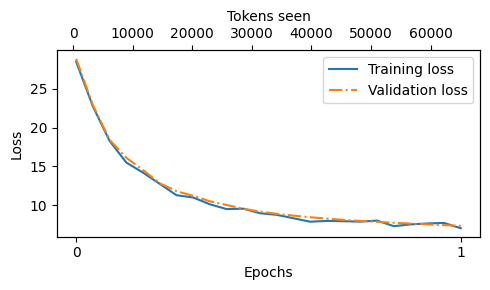

In [317]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [318]:
torch.manual_seed(123)



for entry in test_data[:3]:


    input_text = format_input(entry)


    token_ids = generate(

        model=model,

        idx=text_to_token_ids(input_text, tokenizer).to(device),

        max_new_tokens=256,

        context_size=BASE_CONFIG["context_length"],

        eos_id=50256

    )

    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (

        generated_text[len(input_text):]

        .replace("### Response:", "")

        .strip()

)


    print(input_text)

    print(f"\nCorrect response:\n>> {entry['output']}")

    print(f"\nModel response:\n>> {response_text.strip()}")

    print("-------------------------------------")


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> 
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> 
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> 
-------------------------------------


In [319]:
from tqdm import tqdm


for i, entry in tqdm(enumerate(test_data), total=len(test_data)):


    input_text = format_input(entry)


    token_ids = generate(

        model=model,

        idx=text_to_token_ids(input_text, tokenizer).to(device),

        max_new_tokens=256,

        context_size=BASE_CONFIG["context_length"],

        eos_id=50256

    )

    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()


    test_data[i]["model_response"] = response_text



with open("instruction-data-with-response.json", "w") as file:

    json.dump(test_data, file, indent=4)


100%|██████████| 110/110 [25:00<00:00, 13.64s/it]


In [320]:
print(test_data[0])


{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': ''}


In [321]:
import re



file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"

torch.save(model.state_dict(), file_name)

print(f"Model saved as {file_name}")




Model saved as gpt2-medium355M-sft.pth


In [323]:
from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>